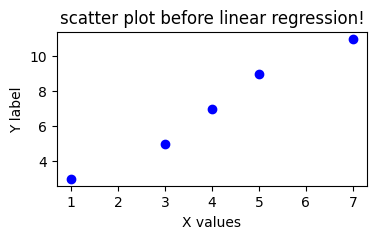

slope and intercept: [1.4] 1.4000000000000004
predicted Values: [ 2.8  5.6  7.   8.4 11.2]


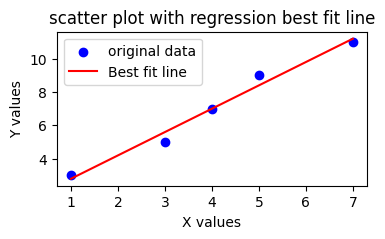

In [ ]:
#01: Simple Linear Regression from Scratch

#goal to find best fit line through scatter points
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
X=np.array([[1],[3],[4],[5],[7]])  #input values (x) -a 2D array
Y=np.array([3,5,7,9,11])           #target values(y) 

#before linear regression
plt.figure(figsize=(4,2))
plt.scatter(X,Y,color='blue')
plt.xlabel('X values')
plt.ylabel('Y label')
plt.title("scatter plot before linear regression!")
plt.show()

#applying linear regression.(finding line to pass between those points on plot)

model=LinearRegression()
model.fit(X,Y)
y_pred=model.predict(X)
m=model.coef_ 
b=model.intercept_
print("slope and intercept:",m,b)
print("predicted Values:",y_pred)


#Scatter and Best Fit line

plt.figure(figsize=(4,2))
plt.scatter(X,Y,color='blue',label='original data')
plt.plot(X,y_pred,color="red",label='Best fit line')
plt.title("scatter plot with regression best fit line")
plt.legend()
plt.xlabel('X values')
plt.ylabel('Y values')
plt.show()

In [ ]:
#02: Decision Tree Classifier on Binary Data set
import numpy as np
from sklearn.tree import DecisionTreeClassifier,export_text
from sklearn.datasets import make_classification

#creating a simple binary data set:
x,y=make_classification(n_samples=10,n_features=2,n_informative=2,n_redundant=0,random_state=42)
feature_names=['feature1','feature2']

print("first 8 data set samples:")
for i in range(8):
    print(f'{feature_names[0]}={x[i,0]:.2f},'
    f'{feature_names[1]}={x[i,1]:.2f},'
    f"class={y[i]}")

tree=DecisionTreeClassifier(
    max_depth=2,  #max depth 2 ,to prevent over fitting
    criterion="gini",
    random_state=42
)
tree.fit(x,y)
print("\n Decision Tree Structure:")
print(export_text(tree,feature_names=feature_names))  #printing tree shape

for name,importance in zip(feature_names,tree.feature_importances_):
    print(f'{name}:{importance:.2f}') #checking feature importances

first 8 data set samples:
feature1=1.07,feature2=-0.97,class=1
feature1=-1.14,feature2=-0.84,class=0
feature1=-2.90,feature2=1.98,class=0
feature1=-0.72,feature2=-0.96,class=0
feature1=-1.96,feature2=-0.99,class=0
feature1=-0.94,feature2=-0.54,class=1
feature1=1.73,feature2=-1.19,class=1
feature1=1.78,feature2=1.51,class=1

 Decision Tree Structure:
|--- feature1 <= 0.24
|   |--- feature2 <= -0.69
|   |   |--- class: 0
|   |--- feature2 >  -0.69
|   |   |--- class: 0
|--- feature1 >  0.24
|   |--- class: 1

feature1:0.83
feature2:0.17


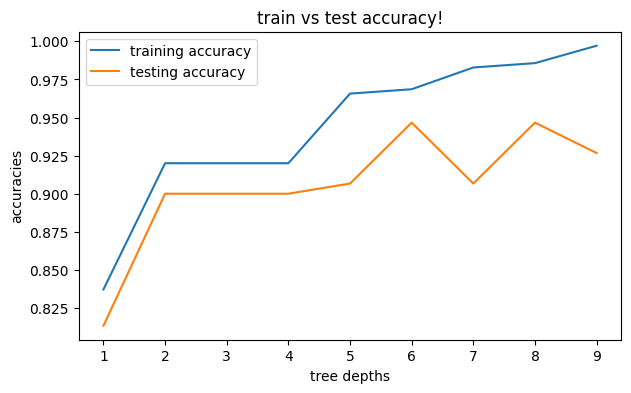

Best Depth based on test accuracy is:6


'"\ninterpretation:\ntraining accuracy rising with depths but test accuracy drops, its overfitting.\n'

In [ ]:
#03: UNDERSTANDING TREE DEPTHS AND OVERFITTING!!

#Experiment: how tree depth affectsoverfitting

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X,y=make_moons(n_samples=500,noise=0.25,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)


#EXPERIMENT:
depths=list(range(1,10)) 
train_acc=[]
test_acc=[]

for d in depths:
    model=DecisionTreeClassifier(
        max_depth=d,
        random_state=42)
    model.fit(X_train,y_train)
    train_predict=model.predict(X_train)
    test_predict=model.predict(X_test)

    train_acc.append(accuracy_score(y_train,train_predict))
    test_acc.append(accuracy_score(y_test,test_predict))
test_acc

#plotting the accuracies with their depths for better understanding
plt.figure(figsize=(7,4))
plt.plot(depths,train_acc,label="training accuracy")
plt.plot(depths,test_acc,label="testing accuracy")
plt.xlabel("tree depths")
plt.ylabel("accuracies")
plt.title("train vs test accuracy!")
plt.legend()
plt.show()

best_depth=depths[np.argmax(test_acc)]
print(f'Best Depth based on test accuracy is:{best_depth}') #best depth=where test accuracy is high

""""
interpretation:
training accuracy rising with depths but test accuracy drops, its overfitting.
"""

In [ ]:
#04:PRE-PRUNNING IN DECISION TREES
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

x,y=make_moons(n_samples=600,random_state=42,noise=0.25)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

#experiment for pre prunning ,max depth is an method/example!
depths=list(range(1,15))
train_acc_pre=[]
test_acc_pre=[]

for d in depths:
    tree=DecisionTreeClassifier(
        max_depth=d,
        random_state=42,
        min_samples_leaf=5 #if any node has reach 5 samples ,then stop splitting and consider it leaf!
    )
    tree.fit(x_train,y_train)
    train_acc_pre.append(accuracy_score(y_train,tree.predict(x_train)))
    test_acc_pre.append(accuracy_score(y_test,tree.predict(x_test)))
print(test_acc_pre)



[0.8111111111111111, 0.8888888888888888, 0.8888888888888888, 0.8888888888888888, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9]


[0.9266666666666666, 0.9266666666666666, 0.9266666666666666, 0.9333333333333333, 0.9333333333333333, 0.8933333333333333, 0.9066666666666666, 0.9066666666666666, 0.9466666666666667, 0.9, 0.8733333333333333, 0.8133333333333334, 0.5]


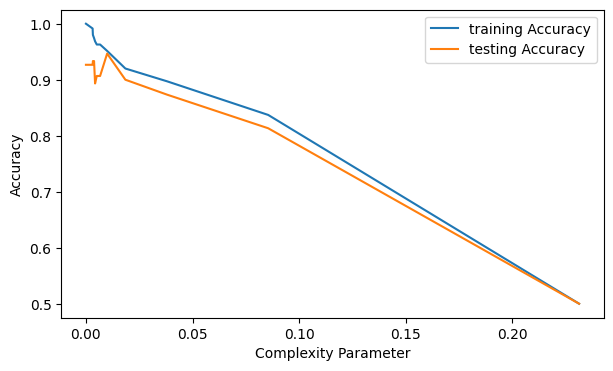

Best value of alpha=0.010
larger ccpa alpha = more aggressive pruning


In [ ]:
#05: POST-PRUNNING IN DECISION TREES
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X,y=make_moons(n_samples=500,noise=0.25,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

train_acc_post=[]
test_acc_post=[]

path=full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas
for alpha in ccp_alphas:
    pruned_tree=DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )
    pruned_tree.fit(X_train,y_train)
    train_acc_post.append(accuracy_score(y_train,pruned_tree.predict(X_train)))
    test_acc_post.append(accuracy_score(y_test,pruned_tree.predict(X_test)))
print(test_acc_post)

plt.figure(figsize=(7,4))
plt.plot(ccp_alphas,train_acc_post,label='training Accuracy')
plt.plot(ccp_alphas,test_acc_post,label="testing Accuracy")
plt.xlabel("Complexity Parameter")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

best_alpha=ccp_alphas[np.argmax(test_acc_post)]
print(f'Best value of alpha={best_alpha:.3f}')
print("larger ccpa alpha = more aggressive pruning")

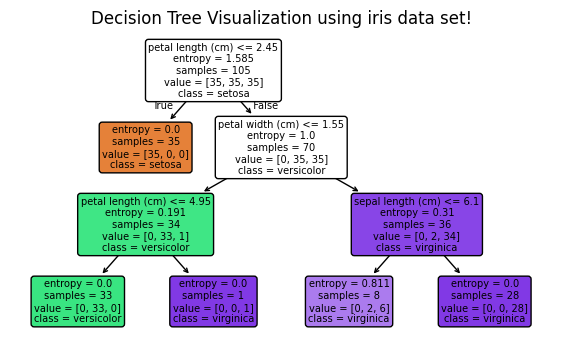

==MODEL PERFORMANCE==

Accuracy:0.9333333333333333

==CONFUSION MATRIX:==
[[15  0  0]
 [ 0 12  3]
 [ 0  0 15]]

==CLASSIFICATION REPORT:==
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



In [ ]:
# 06:Implementation of decision tree
#-- practise model

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier,plot_tree     

data=load_iris()
x=data.data
y=data.target
features=data.feature_names
classes=data.target_names

train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)
model=DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    criterion="entropy"
)
model.fit(train_x,train_y)

plt.figure(figsize=(7,4))
plot_tree(
    model,
    feature_names=features,
    class_names=classes,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization using iris data set!")
plt.show()

y_pred=model.predict(test_x)
print("==MODEL PERFORMANCE==\n")
print(f"Accuracy:{accuracy_score(test_y,y_pred)}\n")
print("==CONFUSION MATRIX:==")
print(confusion_matrix(test_y,y_pred))
print("\n==CLASSIFICATION REPORT:==")
print(classification_report(test_y,y_pred,target_names=classes))